In [161]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from sklearn.svm import SVC
# Preprocessing & Pipelines
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model Selection
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
import seaborn as sns

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)


In [162]:
data = pd.read_csv('clean.csv')

Dataset loaded: 11000 rows, 20 columns
Features (X): 18 columns
Target (y) distribution:
Anxiety_Class
0    5202
1    4661
2    1137
Name: count, dtype: int64

Class balance ratio (%):
Anxiety_Class
0    47.29
1    42.37
2    10.34
Name: count, dtype: float64

Class balance ratio: 5202:4661:1137 (Low : Moderate : High)


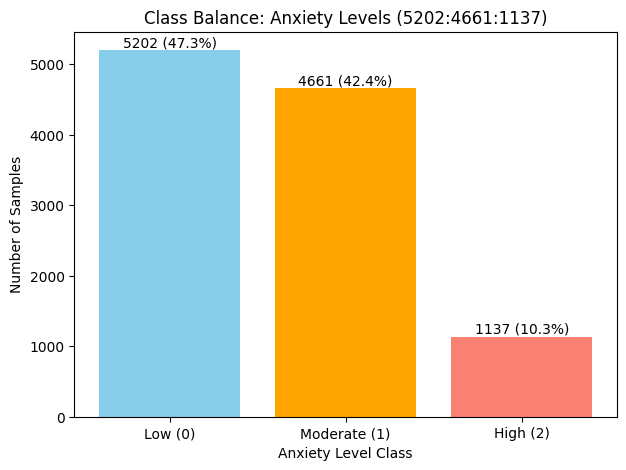

In [163]:
def anxiety_category(x):
    if x <= 3:
        return 0  # Low
    elif x <= 6:
        return 1  # Moderate
    else:
        return 2  # High

data["Anxiety_Class"] = data["Anxiety Level (1-10)"].apply(anxiety_category)
X = data.drop(["Anxiety Level (1-10)", "Anxiety_Class"], axis=1)
y = data["Anxiety_Class"]

# --- Counts and ratios ---
counts = y.value_counts().sort_index()
class_ratio = counts / counts.sum()

# Simplified ratio
g = gcd(counts[0], counts[1]) if len(counts) > 1 else 1
ratio_str = ':'.join(str(counts[i]//g) for i in range(len(counts)))

# --- Print info ---
print(f"Dataset loaded: {data.shape[0]} rows, {data.shape[1]} columns")
print(f"Features (X): {X.shape[1]} columns")
print(f"Target (y) distribution:\n{counts}")
print("\nClass balance ratio (%):")
print((class_ratio * 100).round(2))
print(f"\nClass balance ratio: {ratio_str} (Low : Moderate : High)")

# --- Plot ---
plt.figure(figsize=(7,5))
bars = plt.bar(counts.index.astype(str), counts.values, color=['skyblue','orange','salmon'])
plt.title(f"Class Balance: Anxiety Levels ({ratio_str})")
plt.xlabel("Anxiety Level Class")
plt.ylabel("Number of Samples")
plt.xticks([0,1,2], ["Low (0)", "Moderate (1)", "High (2)"])

# Add count + percentage on top
for bar, ratio in zip(bars, class_ratio):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 5, 
             f"{int(height)} ({ratio*100:.1f}%)", ha='center', va='bottom', fontsize=10)

plt.show()

Identify categorical and numeric columns

In [164]:
num_cols = X.select_dtypes(include=['int64','float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object','category']).columns.tolist()

ONEHOTENCODING AND FEASURE SCALING

In [165]:
preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ]
)

SPLITTING THE DATASET INTO TEST AND TRAIN SET

In [166]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


MODEL PIPELINES

In [167]:
pipelines = {
    "logreg": Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",             # required for multinomial
            random_state=42
        ))
    ]),

    "svm": Pipeline([
        ("preprocess", preprocess),
        ("model", SVC(
            C=1,
            kernel="linear",
            class_weight="balanced",
            probability=True,          
            random_state=42
        ))
    ]),

    "xgb": Pipeline([
        ("preprocess", preprocess),
        ("model", XGBClassifier(
            objective="multi:softprob", 
            num_class=3,
            eval_metric="mlogloss",
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),

    "mlp": Pipeline([
        ("preprocess", preprocess),
        ("scaler", StandardScaler()),  # MLP needs scaled features
        ("model", MLPClassifier(
            max_iter=2000,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10,
            random_state=42
        ))
    ])
}

In [168]:
param_grids = {
    "logreg": {
        "model__C": [0.01, 0.1, 1]
    },
    "svm": {
        "model__C": [0.01, 0.1, 1]
    },
    "xgb": {
        "model__max_depth": [3, 5],
        "model__learning_rate": [0.05, 0.1],
        "model__n_estimators": [200]
    },
    "mlp": {
        "model__hidden_layer_sizes": [(50,), (100,)],
        "model__alpha": [0.0001, 0.001]
    }
}


In [169]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

result={}
cv_macro_f1_scores = []
test_macro_f1_scores = []
model_names = []

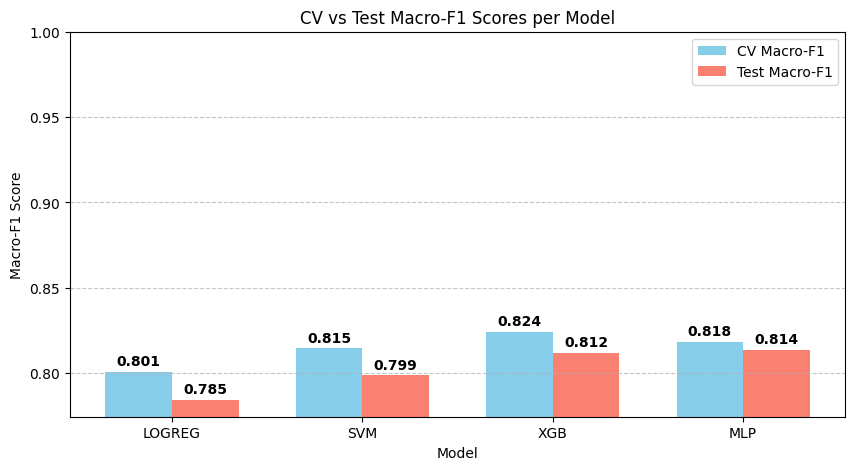

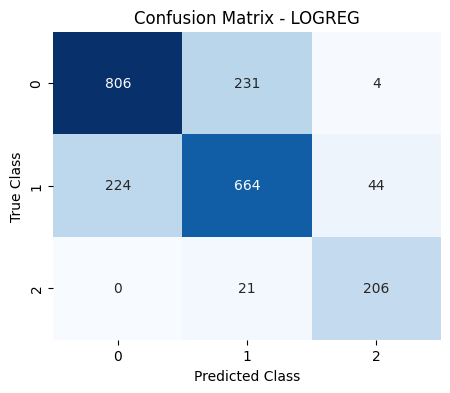

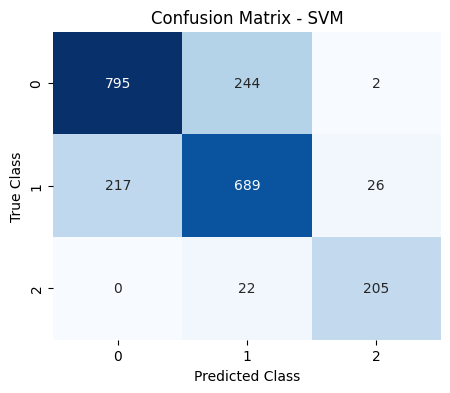

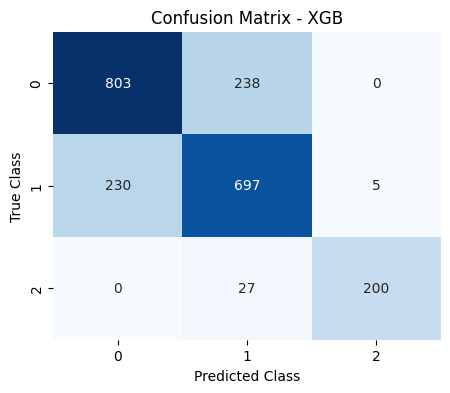

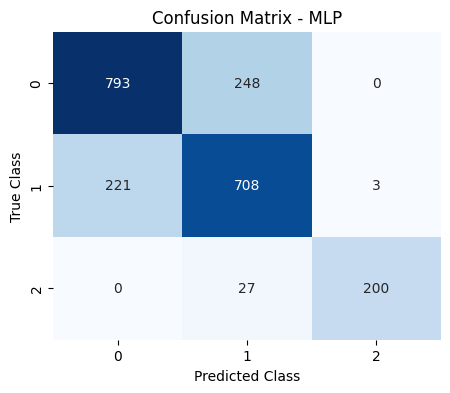

In [170]:

for name, grid in results.items():
    model_names.append(name.upper())
    cv_macro_f1_scores.append(grid.best_score_)  # CV F1
    y_pred = grid.predict(X_test)
    test_macro_f1_scores.append(f1_score(y_test, y_pred, average='macro'))

# ----------------------------
# Plot CV vs Test Macro-F1 (reduced height)
# ----------------------------
x = range(len(model_names))
width = 0.35

plt.figure(figsize=(10,5))
plt.bar([i - width/2 for i in x], cv_macro_f1_scores, width=width, label='CV Macro-F1', color='skyblue')
plt.bar([i + width/2 for i in x], test_macro_f1_scores, width=width, label='Test Macro-F1', color='salmon')

# Add value labels slightly above the bars
for i in x:
    plt.text(i - width/2, cv_macro_f1_scores[i]+0.002, f"{cv_macro_f1_scores[i]:.3f}", ha='center', va='bottom', fontweight='bold')
    plt.text(i + width/2, test_macro_f1_scores[i]+0.002, f"{test_macro_f1_scores[i]:.3f}", ha='center', va='bottom', fontweight='bold')

plt.xticks(x, model_names)
plt.ylim(min(min(cv_macro_f1_scores), min(test_macro_f1_scores)) - 0.01, 1)  # reduce bar heights for clarity
plt.ylabel("Macro-F1 Score")
plt.xlabel("Model")
plt.title("CV vs Test Macro-F1 Scores per Model")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()

# ----------------------------
# Plot Confusion Matrices for each model
# ----------------------------
for name, grid in results.items():
    y_pred = grid.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Confusion Matrix - {name.upper()}")
    plt.xlabel("Predicted Class")
    plt.ylabel("True Class")
    plt.show()

In [171]:
best_model_name = max(results, key=lambda x: results[x].best_score_)
best_model = results[best_model_name].best_estimator_

print(f"\nBest overall model: {best_model_name.upper()}")

y_pred = best_model.predict(X_test)

print("\nTest set performance:")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "High"]))



Best overall model: XGB

Test set performance:
              precision    recall  f1-score   support

         Low       0.78      0.77      0.77      1041
    Moderate       0.72      0.75      0.74       932
        High       0.98      0.88      0.93       227

    accuracy                           0.77      2200
   macro avg       0.83      0.80      0.81      2200
weighted avg       0.78      0.77      0.77      2200




Feature importance for XGB:


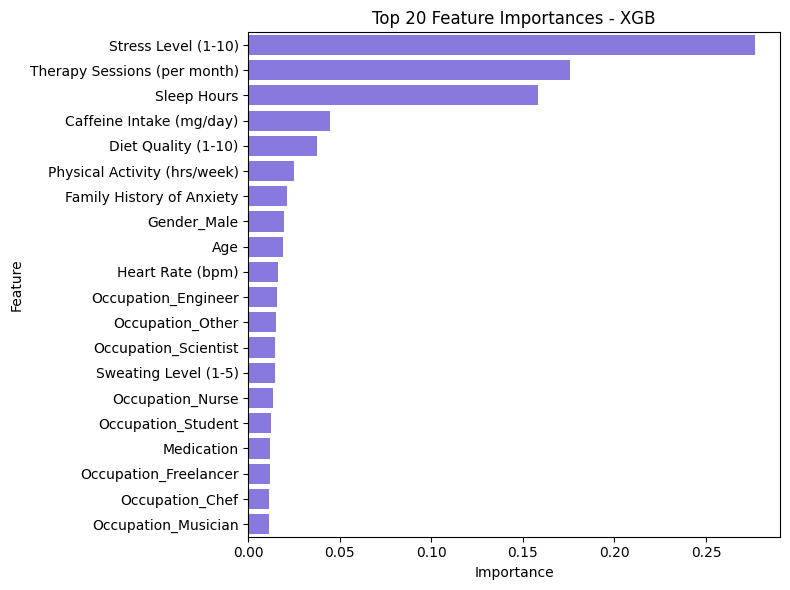

In [172]:
name = "xgb"
grid = results[name]  

print(f"\nFeature importance for {name.upper()}:")

pipe = grid.best_estimator_

# ----------------------------
# 1️⃣ Extract feature names after preprocessing
# ----------------------------
try:
    # Works if preprocess is ColumnTransformer
    feature_names = pipe["preprocess"].get_feature_names_out()
    # Clean names like 'num__age', 'cat__Color_Red' → 'age', 'Color_Red'
    feature_names = [f.split("__")[-1] for f in feature_names]
except AttributeError:
    # Fallback: use original column names (numeric-only)
    feature_names = X_train.columns.tolist()

# ----------------------------
# 2️⃣ Tree-based feature importance
# ----------------------------
importances = pipe["model"].feature_importances_

# ----------------------------
# 3️⃣ Ensure lengths match
# ----------------------------
if len(importances) != len(feature_names):
    print(f"Warning: Mismatch in feature names and importances for {name.upper()}. Adjusting names.")
    feature_names = [f"Feature {i+1}" for i in range(len(importances))]

# ----------------------------
# 4️⃣ Prepare DataFrame and sort
# ----------------------------
feat_df = pd.DataFrame({"feature": feature_names, "importance": importances})
feat_df = feat_df.sort_values(by="importance", ascending=False).head(20)  # Top 20 features

# ----------------------------
# 5️⃣ Plot
# ----------------------------
plt.figure(figsize=(8,6))
sns.barplot(x="importance", y="feature", data=feat_df, color="mediumslateblue")
plt.title(f"Top 20 Feature Importances - {name.upper()}")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()